In [74]:
import os
import numpy as np
import matplotlib.pyplot as plt

def load_metrics_from_npz(npz_path):
    """
    Loads the first array found in an .npz file.
    Assumes that array has shape (N, 4) with columns [MSE, MAPE, MAPE, MAPE].
    Returns:
      mse : 1D array of length N
      mape: 1D array of length N
    """
    data = np.load(npz_path)
    key = data.files[0]
    arr = data[key]  # shape (N, 4)
    mse  = arr[:, 2]
    mape = arr[:, 1]
    return mse, mape

def plot_aligned_runs(
    npz_dirs,
    label_map=None,
    color_map=None
):
    """
    Finds all .npz files in each of the directories listed in npz_dirs,
    loads their (N,4) arrays, and plots MSE and MAPE as side-by-side scatter plots
    aligned so that each file's final run sits at the same x-coordinate.
    
    Args:
      npz_dirs   : List of directory paths to search for .npz files.
      label_map  : Optional dict mapping filename -> custom label.
      color_map  : Optional dict mapping filename -> custom color string.
    """
    # Default Matplotlib color cycle
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    default_idx = 0

    # 1) Gather metrics from all .npz files in all directories
    metrics = []  # list of tuples (fname, N, mse_array, mape_array)
    for dirpath in npz_dirs:
        if not os.path.isdir(dirpath):
            continue
        for fname in os.listdir(dirpath):
            if not fname.endswith(".npz"):
                continue
            full_path = os.path.join(dirpath, fname)
            mse, mape = load_metrics_from_npz(full_path)
            N = len(mse)
            metrics.append((fname, N, mse, mape))

    if not metrics:
        raise RuntimeError(f"No .npz files found in {npz_dirs}")

    # 2) Determine the maximum N among all runs
    max_N = max(N for (_, N, _, _) in metrics)

    # 3) For each file, compute x positions so its last run sits at x = max_N
    aligned_data = []
    for fname, N, mse, mape in metrics:
        x = np.arange(max_N - N + 1, max_N + 1)
        aligned_data.append((fname, x, mse, mape))

    # 4) Create side-by-side subplots for MSE and MAPE
    fig, (ax_mse, ax_mape) = plt.subplots(ncols=2, figsize=(14, 5), sharex=True)
    
    for fname, x, mse, mape in aligned_data:
        # Determine label
        label = label_map.get(fname, fname) if label_map else fname
        # Determine color
        if color_map and fname in color_map:
            color = color_map[fname]
        else:
            color = default_colors[default_idx % len(default_colors)]
            default_idx += 1

        # Scatter MSE
        ax_mse.scatter(x, mse, color=color, alpha=0.3, label=label)
        # Scatter MAPE
        ax_mape.scatter(x, mape, color=color, alpha=0.3, label=label)

    # Configure MSE subplot
    ax_mse.set_xlabel(f"Discharge # (Chronologically Ordered)")
    ax_mse.set_ylabel("MSE ($V^2$)")
    ax_mse.grid(alpha=0.3)
    ax_mse.legend(loc='best', fontsize=9)

    # Configure MAPE subplot
    ax_mape.set_xlabel(f"Discharge # (Chronologically Ordered)")
    ax_mape.set_ylabel("MAPE (%)")
    ax_mape.grid(alpha=0.5)
    #ax_mape.legend(loc='best', fontsize=9)

    plt.tight_layout()
    plt.savefig(f"BattNNStaticVsRolling.png", dpi=300, bbox_inches='tight')
    plt.show()

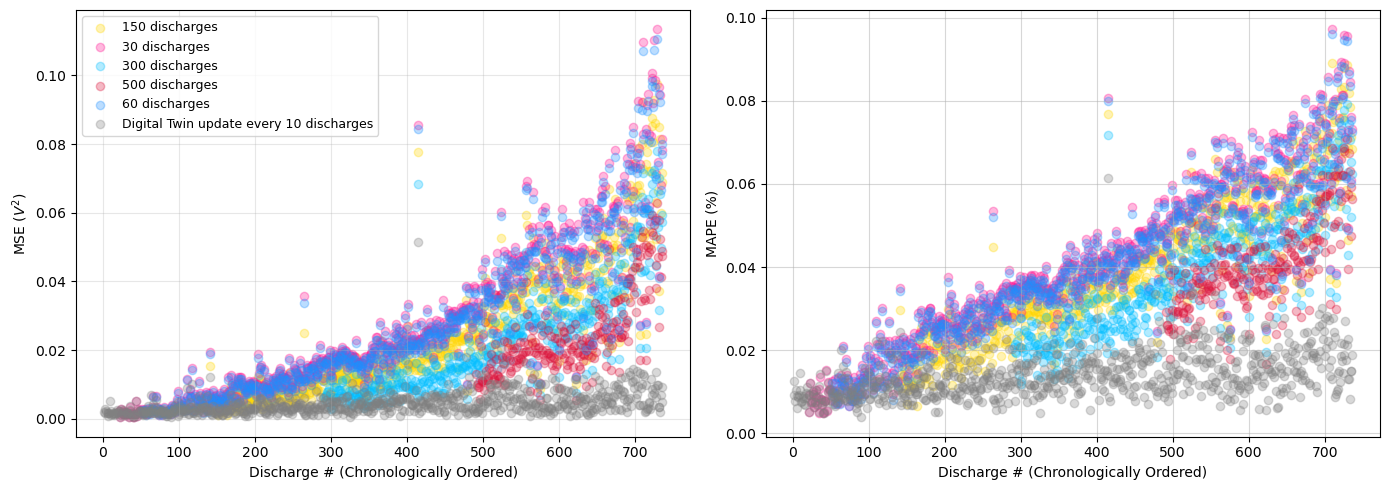

In [88]:
dirs = ["static_training/variational/results/", "rolling_training/variational/results/"]
labels = {"vBattNN-NASA-batch_size=30-seq_len=30.npz": "30 discharges", 
          "vBattNN-NASA-batch_size=60-seq_len=30.npz": "60 discharges",
          "vBattNN-NASA-batch_size=150-seq_len=30.npz": "150 discharges",
          "vBattNN-NASA-batch_size=300-seq_len=30.npz": "300 discharges",
          "vBattNN-NASA-batch_size=500-seq_len=30.npz": "500 discharges",
          "vBattNN-NASA-batch_size=300-seq_len=30.npz": "300 discharges",
          "RollingVBattNN-NASA-batch_size=30-seq_len=30.npz": "Digital Twin update every 10 discharges"
         }
colors = {"vBattNN-NASA-batch_size=30-seq_len=30.npz": "deeppink", 
          "vBattNN-NASA-batch_size=60-seq_len=30.npz": "dodgerblue",
          "vBattNN-NASA-batch_size=150-seq_len=30.npz": "gold",
          "vBattNN-NASA-batch_size=300-seq_len=30.npz": "deepskyblue",
          "vBattNN-NASA-batch_size=500-seq_len=30.npz": "crimson",
          "RollingVBattNN-NASA-batch_size=30-seq_len=30.npz": "gray"
         }

plot_aligned_runs(dirs, label_map=labels, color_map=colors)

In [100]:
import pandas as pd

def load_metrics_from_npz(npz_path):
    """
    Loads the first array found in an .npz file.
    Assumes that array has shape (N, 4) with columns [MAE, MAPE, MSE, RMSE].
    Returns:
      mse  : 1D array of length N
      mape : 1D array of length N
      rmse : 1D array of length N
    """
    data = np.load(npz_path)
    key = data.files[0]
    arr = data[key]  # shape (N, 4)
    mape = arr[:, 1]
    mse  = arr[:, 2]
    rmse = arr[:, 3]
    return mse, mape, rmse

def collect_average_metrics(npz_dirs):
    """
    Searches each directory in npz_dirs for .npz files, loads their (N,4) arrays,
    computes the average MSE, MAPE, and RMSE for each file, and returns a DataFrame.
    
    Args:
      npz_dirs: List of directory paths to search for .npz files.
    
    Returns:
      pd.DataFrame with columns:
        'filename', 'avg_mse', 'avg_mape', 'avg_rmse'
    """
    records = []
    for dirpath in npz_dirs:
        if not os.path.isdir(dirpath):
            continue
        for fname in os.listdir(dirpath):
            if not fname.endswith(".npz"):
                continue
            full_path = os.path.join(dirpath, fname)
            mse, mape, rmse = load_metrics_from_npz(full_path)
            records.append({
                'filename': fname,
                'avg_mse':  float(np.mean(mse)),
                'avg_mape': float(np.mean(mape)),
                'avg_rmse': float(np.mean(rmse))
            })

    if not records:
        raise RuntimeError(f"No .npz files found in {npz_dirs}")

    df = pd.DataFrame(records)
    return df


df_metrics = collect_average_metrics(dirs)
df_metrics['Training Procedure'] = ["DT Update, 10 runs/update", "Static, 150 runs", "Static, 30 runs", "Static, 300 runs", "Static, 500 runs", "Static, 60 runs"]
df_metrics

,filename,avg_mse,avg_mape,avg_rmse,Training Procedure
0,RollingVBattNN-NASA-batch_size=30-seq_len=30.npz,0.004535,0.014055,0.063663,"DT Update, 10 runs/update"
1,vBattNN-NASA-batch_size=150-seq_len=30.npz,0.025122,0.039195,0.147181,"Static, 150 runs"
2,vBattNN-NASA-batch_size=30-seq_len=30.npz,0.027116,0.039892,0.149652,"Static, 30 runs"
3,vBattNN-NASA-batch_size=300-seq_len=30.npz,0.022707,0.037708,0.142274,"Static, 300 runs"
4,vBattNN-NASA-batch_size=500-seq_len=30.npz,0.024531,0.040522,0.152288,"Static, 500 runs"
5,vBattNN-NASA-batch_size=60-seq_len=30.npz,0.027245,0.040367,0.151290,"Static, 60 runs"
